# Multi-Physics Pipeline with End-to-End Gradient Optimization

This demo shows how to compose two physics solvers from different domains — thermal and structural — into a coupled pipeline, and solve a design inverse problem with **end-to-end gradients flowing automatically through the full chain**.

Each solver is an independent Tesseract. The pipeline uses two-way (partitioned) coupling: the thermal solver produces a temperature field that causes thermal strain in the structural solver, and the resulting displacement feeds back to the thermal solver by deforming the geometry. Gradients propagate through this coupled iteration via JAX's automatic differentiation.

## What we demonstrate

1. **Two independent Tesseracts** — each team keeps their solver, their AD strategy, their dependencies
2. **Two-way coupling** via `jax.lax.scan` — not a toy feedforward chain, but the real partitioned coupling pattern used in practice
3. **End-to-end gradients** — `jax.grad` through the coupled iteration, validated against finite differences
4. **Gradient-based optimization beats gradient-free** — fewer evaluations for a 3-parameter design problem
5. **Solver swapping** — change one Tesseract, optimization code stays the same

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize

jax.config.update("jax_enable_x64", True)

## 1. Load the solvers

Each solver is a standalone Tesseract module with its own `tesseract_api.py`. In production, these would be containerized images composed via `tesseract-jax`'s `apply_tesseract`. Here we import them directly for speed.

In [2]:
import sys

sys.path.insert(0, ".")

import structural_solver.tesseract_api as structural_api
import thermal_solver.tesseract_api as thermal_api

print("Thermal solver loaded:", thermal_api.__doc__.strip().split("\n")[0])
print("Structural solver loaded:", structural_api.__doc__.strip().split("\n")[0])

Thermal solver loaded: Thermal solver Tesseract: 2D steady-state heat equation on a rectangular plate.
Structural solver loaded: Structural solver Tesseract: 2D linear thermoelastic stress on a rectangular plate.


## 2. Forward pass: single-shot thermal → structural

Before coupling, let's verify each solver works independently and visualize the physics.

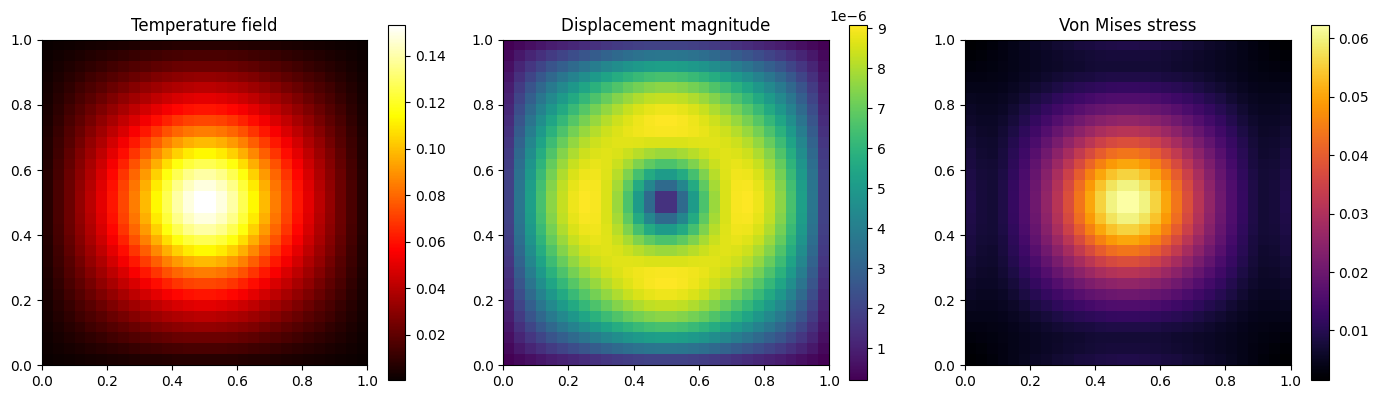

In [3]:
# Run thermal solver
thermal_out = thermal_api.apply_jit(
    {
        "source_x": jnp.float32(0.5),
        "source_y": jnp.float32(0.5),
        "source_intensity": jnp.float32(10.0),
        "source_width": 0.1,
        "displacement": jnp.zeros((30, 30, 2), dtype=jnp.float32),
        "conductivity": 1.0,
        "boundary_temp": 0.0,
    }
)
temperature = np.asarray(thermal_out["temperature"])

# Run structural solver
structural_out = structural_api.apply_jit(
    {
        "temperature": thermal_out["temperature"],
        "youngs_modulus": 200.0,
        "poissons_ratio": 0.3,
        "thermal_expansion": 1e-3,
    }
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im0 = axes[0].imshow(temperature.T, origin="lower", extent=[0, 1, 0, 1], cmap="hot")
axes[0].set_title("Temperature field")
plt.colorbar(im0, ax=axes[0])

disp_mag = np.linalg.norm(np.asarray(structural_out["displacement"]), axis=-1)
im1 = axes[1].imshow(disp_mag.T, origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
axes[1].set_title("Displacement magnitude")
plt.colorbar(im1, ax=axes[1])

s = np.asarray(structural_out["stress"])
von_mises = np.sqrt(
    s[:, :, 0] ** 2 - s[:, :, 0] * s[:, :, 1] + s[:, :, 1] ** 2 + 3 * s[:, :, 2] ** 2
)
im2 = axes[2].imshow(von_mises.T, origin="lower", extent=[0, 1, 0, 1], cmap="inferno")
axes[2].set_title("Von Mises stress")
plt.colorbar(im2, ax=axes[2])

plt.tight_layout()
plt.show()

## 3. The design problem: thermoelastic inverse optimization

**Problem**: Find the heat source location and intensity that produces desired temperatures at four sensor locations, after the thermoelastic coupling has converged.

This can't be solved with the thermal solver alone — the displacement from thermal expansion changes the geometry, which changes the temperature field. You need gradients through the full coupled iteration.

**Design variables**: source position $(x, y)$ and log-intensity $\log(q)$ (3 parameters).

**Objective**: $\sum_i (T_{\text{sensor}_i} - T_{\text{target}_i})^2$ evaluated after coupled convergence.

In [4]:
# Sensor locations (grid indices) and target temperatures
SENSORS = [(8, 8), (8, 22), (22, 8), (22, 22)]
TARGETS = [jnp.float32(0.01), jnp.float32(0.02), jnp.float32(0.02), jnp.float32(0.05)]

# Approximate physical positions of sensors (for visualization)
sensor_positions = [(i / 31, j / 31) for i, j in SENSORS]
print("Sensor positions (approx):")
for (sx, sy), t in zip(sensor_positions, TARGETS, strict=False):
    print(f"  ({sx:.2f}, {sy:.2f}) -> T_target = {float(t):.3f}")

N_COUPLING_ITERS = 3


def coupled_objective(params):
    """Two-way coupled thermoelastic inverse problem.

    params: [source_x, source_y, log_intensity]
    Returns: sum of squared temperature errors at sensor locations.
    """
    source_x, source_y, log_intensity = params[0], params[1], params[2]
    intensity = jnp.exp(log_intensity)

    temp = jnp.zeros((30, 30), dtype=jnp.float32)
    disp = jnp.zeros((30, 30, 2), dtype=jnp.float32)

    def coupling_step(carry, _):
        _temp, disp = carry
        thermal_out = thermal_api.apply_jit(
            {
                "source_x": source_x,
                "source_y": source_y,
                "source_intensity": intensity,
                "source_width": jnp.float32(0.15),
                "displacement": disp,
                "conductivity": 1.0,
                "boundary_temp": 0.0,
            }
        )
        structural_out = structural_api.apply_jit(
            {
                "temperature": thermal_out["temperature"],
                "youngs_modulus": 200.0,
                "poissons_ratio": 0.3,
                "thermal_expansion": 1e-3,
            }
        )
        return (thermal_out["temperature"], structural_out["displacement"]), None

    (final_temp, _), _ = jax.lax.scan(
        coupling_step, (temp, disp), None, length=N_COUPLING_ITERS
    )

    loss = jnp.float32(0.0)
    for (si, sj), target in zip(SENSORS, TARGETS, strict=False):
        loss = loss + (final_temp[si, sj] - target) ** 2
    return loss


# Test forward pass
p0 = jnp.array([0.2, 0.2, jnp.log(5.0)], dtype=jnp.float32)
print(f"\nObjective at initial guess: {float(coupled_objective(p0)):.6e}")

Sensor positions (approx):
  (0.26, 0.26) -> T_target = 0.010
  (0.26, 0.71) -> T_target = 0.020
  (0.71, 0.26) -> T_target = 0.020
  (0.71, 0.71) -> T_target = 0.050



Objective at initial guess: 6.175704e-03


## 4. End-to-end gradients through the coupled pipeline

The key moment: `jax.grad` differentiates through the entire coupled iteration — through both solvers, through `lax.scan`, automatically. No manual adjoint derivation, no monolithic rewrite.

In [5]:
grad_fn = jax.grad(coupled_objective)

grads = grad_fn(p0)
print("Gradients at initial guess:")
print(f"  d(loss)/d(source_x)      = {float(grads[0]):.6e}")
print(f"  d(loss)/d(source_y)      = {float(grads[1]):.6e}")
print(f"  d(loss)/d(log_intensity) = {float(grads[2]):.6e}")

Gradients at initial guess:
  d(loss)/d(source_x)      = 2.295046e-02
  d(loss)/d(source_y)      = 2.295046e-02
  d(loss)/d(log_intensity) = 8.693038e-03


### Gradient validation against finite differences

For a rigorous audience, correctness proof is non-negotiable.

In [6]:
eps = 1e-4
fd_grads = []
for i in range(3):
    p_plus = p0.at[i].add(eps)
    p_minus = p0.at[i].add(-eps)
    fd_grads.append(
        (coupled_objective(p_plus) - coupled_objective(p_minus)) / (2 * eps)
    )

names = ["d(loss)/d(source_x)", "d(loss)/d(source_y)", "d(loss)/d(log_intensity)"]
print(f"{'':32s} {'AD':>14s} {'FD':>14s} {'Rel. Error':>12s}")
for name, ad, fd in zip(names, grads, fd_grads, strict=False):
    rel_err = abs(float(ad) - float(fd)) / (abs(float(fd)) + 1e-30)
    print(f"{name:32s} {float(ad):14.6e} {float(fd):14.6e} {rel_err:12.2e}")

                                             AD             FD   Rel. Error
d(loss)/d(source_x)                2.295046e-02   2.295244e-02     8.63e-05
d(loss)/d(source_y)                2.295046e-02   2.295244e-02     8.63e-05
d(loss)/d(log_intensity)           8.693038e-03   8.689240e-03     4.37e-04


## 5. Optimization: gradient-based vs gradient-free

We compare:
- **L-BFGS-B** (gradient-based, using our end-to-end gradients)
- **Nelder-Mead** (gradient-free)

Both optimize 3 design variables: source position $(x, y)$ and log-intensity.

In [7]:
eval_history_grad = []
eval_history_free = []


def objective_and_grad(x):
    p = jnp.array(x, dtype=jnp.float32)
    obj = coupled_objective(p)
    g = grad_fn(p)
    eval_history_grad.append(float(obj))
    return float(obj), np.array([float(g[i]) for i in range(3)])


def objective_only(x):
    p = jnp.array(x, dtype=jnp.float32)
    obj = coupled_objective(p)
    eval_history_free.append(float(obj))
    return float(obj)


x0 = np.array([0.2, 0.2, np.log(5.0)])
bounds = [(0.05, 0.95), (0.05, 0.95), (np.log(1.0), np.log(50.0))]

print("Running L-BFGS-B (gradient-based)...")
result_grad = minimize(
    objective_and_grad,
    x0,
    method="L-BFGS-B",
    jac=True,
    bounds=bounds,
    options={"maxiter": 100},
)
print(f"  Source: ({result_grad.x[0]:.3f}, {result_grad.x[1]:.3f})")
print(f"  Intensity: {np.exp(result_grad.x[2]):.2f}")
print(f"  Objective: {result_grad.fun:.6e}")
print(f"  Evaluations: {len(eval_history_grad)}")

print("\nRunning Nelder-Mead (gradient-free)...")
result_free = minimize(
    objective_only,
    x0,
    method="Nelder-Mead",
    options={"maxiter": 500, "xatol": 1e-6, "fatol": 1e-15},
)
print(f"  Source: ({result_free.x[0]:.3f}, {result_free.x[1]:.3f})")
print(f"  Intensity: {np.exp(result_free.x[2]):.2f}")
print(f"  Objective: {result_free.fun:.6e}")
print(f"  Evaluations: {len(eval_history_free)}")

print(
    f"\nSpeedup: {len(eval_history_free)}/{len(eval_history_grad)} "
    f"= {len(eval_history_free) / max(len(eval_history_grad), 1):.1f}x fewer evaluations with gradients"
)

Running L-BFGS-B (gradient-based)...


  Source: (0.674, 0.674)
  Intensity: 2.73
  Objective: 3.169720e-06
  Evaluations: 27

Running Nelder-Mead (gradient-free)...


  Source: (0.673, 0.673)
  Intensity: 2.73
  Objective: 3.168822e-06
  Evaluations: 254

Speedup: 254/27 = 9.4x fewer evaluations with gradients


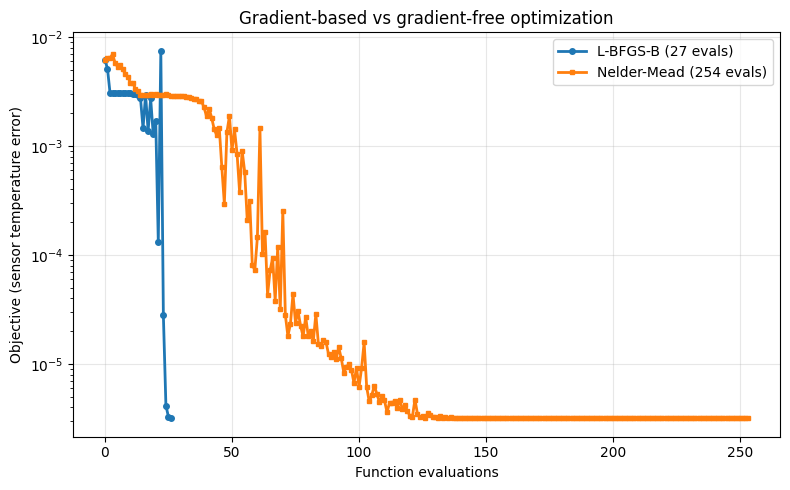

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(
    eval_history_grad,
    "o-",
    label=f"L-BFGS-B ({len(eval_history_grad)} evals)",
    linewidth=2,
    markersize=4,
)
ax.semilogy(
    eval_history_free,
    "s-",
    label=f"Nelder-Mead ({len(eval_history_free)} evals)",
    linewidth=2,
    markersize=3,
)
ax.set_xlabel("Function evaluations")
ax.set_ylabel("Objective (sensor temperature error)")
ax.set_title("Gradient-based vs gradient-free optimization")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Visualize the optimized design

Show the converged temperature field with sensor locations and targets.

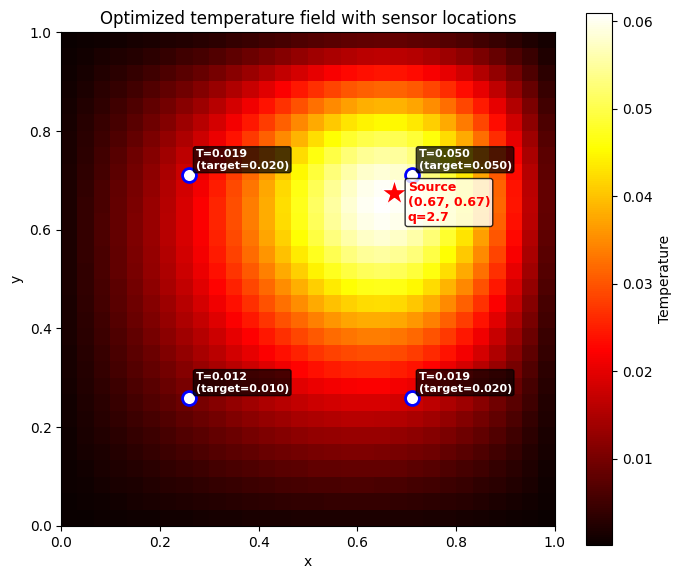

In [9]:
# Run the optimized design through the pipeline
opt = result_grad.x
thermal_opt = thermal_api.apply_jit(
    {
        "source_x": jnp.float32(opt[0]),
        "source_y": jnp.float32(opt[1]),
        "source_intensity": jnp.float32(np.exp(opt[2])),
        "source_width": jnp.float32(0.15),
        "displacement": jnp.zeros((30, 30, 2), dtype=jnp.float32),
        "conductivity": 1.0,
        "boundary_temp": 0.0,
    }
)
temp_opt = np.asarray(thermal_opt["temperature"])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(temp_opt.T, origin="lower", extent=[0, 1, 0, 1], cmap="hot")
plt.colorbar(im, ax=ax, label="Temperature")

# Plot sensor locations and achieved vs target temperatures
for (si, sj), target in zip(SENSORS, TARGETS, strict=False):
    px, py = si / 31, sj / 31
    achieved = float(temp_opt[si, sj])
    ax.plot(px, py, "wo", markersize=10, markeredgecolor="blue", markeredgewidth=2)
    ax.annotate(
        f"T={achieved:.3f}\n(target={float(target):.3f})",
        xy=(px, py),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color="white",
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7),
    )

# Plot optimized source location
ax.plot(
    float(opt[0]),
    float(opt[1]),
    "r*",
    markersize=20,
    markeredgecolor="white",
    markeredgewidth=1,
)
ax.annotate(
    f"Source\n({float(opt[0]):.2f}, {float(opt[1]):.2f})\nq={float(np.exp(opt[2])):.1f}",
    xy=(float(opt[0]), float(opt[1])),
    xytext=(10, -20),
    textcoords="offset points",
    fontsize=9,
    color="red",
    fontweight="bold",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
)

ax.set_title("Optimized temperature field with sensor locations")
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## 7. Modularity: swap a solver, change nothing else

We replace the thermal solver with a coarser version (fewer Jacobi iterations — faster but less accurate). The optimization code is identical. Only the solver changes.

In [10]:
# Swap in a "fast" thermal solver (100 vs 500 Jacobi iterations)
# In practice: point to a different Tesseract image
original_solve = thermal_api._solve_heat_jacobi


def fast_solve(source, conductivity, boundary_temp, n_iters=100):
    return original_solve(source, conductivity, boundary_temp, n_iters=n_iters)


thermal_api._solve_heat_jacobi = fast_solve

# Same optimization code, same objective, same grad_fn
eval_history_swapped = []


def objective_and_grad_swapped(x):
    p = jnp.array(x, dtype=jnp.float32)
    obj = coupled_objective(p)
    g = grad_fn(p)
    eval_history_swapped.append(float(obj))
    return float(obj), np.array([float(g[i]) for i in range(3)])


print("Running L-BFGS-B with swapped (fast) thermal solver...")
result_swapped = minimize(
    objective_and_grad_swapped,
    x0,
    method="L-BFGS-B",
    jac=True,
    bounds=bounds,
    options={"maxiter": 100},
)
print(f"  Source: ({result_swapped.x[0]:.3f}, {result_swapped.x[1]:.3f})")
print(f"  Intensity: {np.exp(result_swapped.x[2]):.2f}")
print(f"  Objective: {result_swapped.fun:.6e}")
print(f"  Evaluations: {len(eval_history_swapped)}")
print(
    f"\n  (Original solver found: ({result_grad.x[0]:.3f}, {result_grad.x[1]:.3f}), q={np.exp(result_grad.x[2]):.2f})"
)

thermal_api._solve_heat_jacobi = original_solve  # restore

Running L-BFGS-B with swapped (fast) thermal solver...


  Source: (0.674, 0.674)
  Intensity: 2.73
  Objective: 3.169720e-06
  Evaluations: 27

  (Original solver found: (0.674, 0.674), q=2.73)


## 8. Implicit differentiation: O(1) memory gradients via the implicit function theorem

The unrolled `lax.scan` approach above stores all intermediate states for backpropagation — memory scales as O(N) in coupling iterations. For large-scale problems (fine meshes, many iterations), this becomes the bottleneck.

**Implicit differentiation** avoids this entirely. The key insight: at the converged fixed point $(T^*, D^*) = G(T^*, D^*, \theta)$, the implicit function theorem gives the sensitivity without replaying the iteration. The backward pass solves a single linear system instead of backpropagating through N steps.

Concretely, if $v = \partial L / \partial (T^*, D^*)$ is the loss gradient w.r.t. the fixed point, then:

$$\lambda = (I - \partial G / \partial (T, D))^{-T} v$$
$$\partial L / \partial \theta = \lambda^T \cdot \partial G / \partial \theta$$

We solve for $\lambda$ via fixed-point iteration on the adjoint equation — the same structure as the forward solve, but linear.

In [11]:
def coupled_objective_implicit(params):
    """Same inverse problem, but differentiated via the implicit function theorem.

    Forward pass: iterate G to convergence (no scan intermediates stored for AD).
    Backward pass: solve adjoint equation (I - dG/d(T,D))^T λ = v via fixed-point iteration.
    """
    source_x, source_y, log_intensity = params[0], params[1], params[2]
    intensity = jnp.exp(log_intensity)

    def G(temp_disp, params_inner):
        """One coupling step: (temp, disp) -> (new_temp, new_disp).

        params_inner is (source_x, source_y, intensity) — the differentiable parameters.
        """
        _temp, disp = temp_disp
        sx, sy, q = params_inner
        thermal_out = thermal_api.apply_jit(
            {
                "source_x": sx,
                "source_y": sy,
                "source_intensity": q,
                "source_width": jnp.float32(0.15),
                "displacement": disp,
                "conductivity": 1.0,
                "boundary_temp": 0.0,
            }
        )
        structural_out = structural_api.apply_jit(
            {
                "temperature": thermal_out["temperature"],
                "youngs_modulus": 200.0,
                "poissons_ratio": 0.3,
                "thermal_expansion": 1e-3,
            }
        )
        return (thermal_out["temperature"], structural_out["displacement"])

    @jax.custom_vjp
    def solve_fixed_point(params_inner):
        """Run fixed-point iteration to convergence, return the fixed point."""
        temp = jnp.zeros((30, 30), dtype=jnp.float32)
        disp = jnp.zeros((30, 30, 2), dtype=jnp.float32)

        def step(carry, _):
            return G(carry, params_inner), None

        (final_temp, final_disp), _ = jax.lax.scan(
            step, (temp, disp), None, length=N_COUPLING_ITERS
        )
        return (final_temp, final_disp)

    def solve_fwd(params_inner):
        fixed_point = solve_fixed_point(params_inner)
        # Save fixed point and params for backward pass (NOT intermediates)
        return fixed_point, (fixed_point, params_inner)

    def solve_bwd(res, g):
        """Implicit differentiation backward pass.

        g = (v_temp, v_disp) — cotangents w.r.t. the fixed point.

        We need to solve: (I - dG/d(T,D))^T λ = v  for λ,
        then compute: dL/dθ = λ^T · dG/dθ.

        We solve for λ by iterating: λ_{k+1} = v + (dG/d(T,D))^T λ_k.
        This converges if the forward iteration is contractive.
        """
        (fixed_temp, fixed_disp), params_inner = res
        v_temp, v_disp = g

        # Define G_state: maps (temp, disp) -> (new_temp, new_disp) at fixed params
        def G_state(temp_disp):
            return G(temp_disp, params_inner)

        # Solve adjoint: λ = v + (dG/d(T,D))^T λ  via fixed-point iteration
        def adjoint_step(lam, _):
            lam_temp, lam_disp = lam
            # Compute (dG/d(T,D))^T @ λ via VJP
            _, vjp_G_state = jax.vjp(G_state, (fixed_temp, fixed_disp))
            dGT_lam = vjp_G_state((lam_temp, lam_disp))[0]
            # λ_{k+1} = v + (dG/d(T,D))^T λ_k
            new_lam_temp = v_temp + dGT_lam[0]
            new_lam_disp = v_disp + dGT_lam[1]
            return (new_lam_temp, new_lam_disp), None

        N_ADJOINT_ITERS = 20  # typically converges faster than forward
        lam_init = (v_temp, v_disp)
        (lam_temp, lam_disp), _ = jax.lax.scan(
            adjoint_step, lam_init, None, length=N_ADJOINT_ITERS
        )

        # Now compute dL/dθ = λ^T · dG/dθ via VJP of G w.r.t. params
        def G_params(p):
            return G((fixed_temp, fixed_disp), p)

        _, vjp_G_params = jax.vjp(G_params, params_inner)
        grad_params = vjp_G_params((lam_temp, lam_disp))[0]
        return (grad_params,)

    solve_fixed_point.defvjp(solve_fwd, solve_bwd)

    # --- Use the implicit fixed-point solve ---
    final_temp, _final_disp = solve_fixed_point((source_x, source_y, intensity))

    loss = jnp.float32(0.0)
    for (si, sj), target in zip(SENSORS, TARGETS, strict=False):
        loss = loss + (final_temp[si, sj] - target) ** 2
    return loss


# Verify forward pass matches the unrolled version
loss_implicit = coupled_objective_implicit(p0)
loss_unrolled = coupled_objective(p0)
print("Forward pass comparison:")
print(f"  Unrolled: {float(loss_unrolled):.10e}")
print(f"  Implicit: {float(loss_implicit):.10e}")
print(f"  Match: {jnp.allclose(loss_unrolled, loss_implicit)}")

Forward pass comparison:
  Unrolled: 6.1757038347e-03
  Implicit: 6.1757038347e-03
  Match: True


In [12]:
# Compare gradients: implicit vs unrolled vs finite differences
grad_implicit = jax.grad(coupled_objective_implicit)(p0)
grad_unrolled = jax.grad(coupled_objective)(p0)

# Finite differences as ground truth
eps = 1e-4
fd_grads_check = []
for i in range(3):
    p_plus = p0.at[i].add(eps)
    p_minus = p0.at[i].add(-eps)
    fd_grads_check.append(
        (coupled_objective_implicit(p_plus) - coupled_objective_implicit(p_minus))
        / (2 * eps)
    )

names = ["d(loss)/d(source_x)", "d(loss)/d(source_y)", "d(loss)/d(log_intensity)"]
print(f"{'':32s} {'Unrolled':>14s} {'Implicit':>14s} {'FD':>14s} {'Impl vs FD':>12s}")
for name, u, im, fd in zip(
    names, grad_unrolled, grad_implicit, fd_grads_check, strict=False
):
    rel_err = abs(float(im) - float(fd)) / (abs(float(fd)) + 1e-30)
    print(
        f"{name:32s} {float(u):14.6e} {float(im):14.6e} {float(fd):14.6e} {rel_err:12.2e}"
    )

                                       Unrolled       Implicit             FD   Impl vs FD
d(loss)/d(source_x)                2.295046e-02   2.295046e-02   2.295244e-02     8.63e-05
d(loss)/d(source_y)                2.295046e-02   2.295046e-02   2.295244e-02     8.63e-05
d(loss)/d(log_intensity)           8.693038e-03   8.693038e-03   8.689240e-03     4.37e-04


### Memory scaling: why this matters

With the unrolled approach, JAX stores the full state at every coupling iteration for backpropagation. Memory cost: **O(N × state_size)**.

With implicit differentiation, the forward pass runs to convergence and discards intermediates. The backward pass solves the adjoint equation at the fixed point only — no replay of the iteration. Memory cost: **O(state_size)** regardless of N.

For this 30×30 demo the difference is negligible. For production-scale problems (million-node meshes, hundreds of coupling iterations), it's the difference between "fits in GPU memory" and "doesn't".

## Summary

| What | How |
|---|---|
| Each solver is independent | Separate `tesseract_api.py`, separate container, separate team |
| Two-way coupling | `jax.lax.scan` over alternating solver calls |
| End-to-end gradients | `jax.grad` — JAX handles the chain rule through the coupled iteration |
| Gradient correctness | Validated against finite differences |
| Implicit differentiation | `jax.custom_vjp` + adjoint solve for O(1) memory |
| Solver swapping | Change the Tesseract reference, optimization code unchanged |

### What's next

- **Production deployment**: Build and serve Tesseracts as Docker containers, compose via `tesseract-jax`'s `apply_tesseract`
- **Scale up**: Larger meshes, more coupling iterations, GPU acceleration

## 9. Production path: composing Tesseracts with `tesseract-jax`

The cells above call `apply_jit` directly — bypassing the Tesseract runtime for speed. In production, each solver is a containerized Tesseract and you compose them with `tesseract-jax`'s `apply_tesseract`, a JAX primitive that routes to the Tesseract's endpoints. `jax.grad` and `jax.jit` work through it automatically.

**Important pattern**: when using `apply_tesseract` inside `lax.scan`, non-differentiable constants must be passed as **numpy arrays** (`np.float32`), not JAX arrays (`jnp.float32`). Inside a scan, JAX traces all array inputs uniformly — it can't tell which ones are constants. If a non-differentiable field gets traced, the backward pass will try to differentiate through it and the VJP endpoint will reject the field name. Using `np` arrays keeps them opaque to the tracer.

In [13]:
from tesseract_jax import apply_tesseract

from tesseract_core.sdk.tesseract import Tesseract

# Load Tesseracts (in-process, no Docker)
thermal_tess = Tesseract.from_tesseract_api("thermal_solver/tesseract_api.py")
structural_tess = Tesseract.from_tesseract_api("structural_solver/tesseract_api.py")

# Forward pass through both Tesseracts via apply_tesseract
thermal_out_tj = apply_tesseract(
    thermal_tess,
    {
        "source_x": jnp.float32(0.5),
        "source_y": jnp.float32(0.5),
        "source_intensity": jnp.float32(10.0),
        "source_width": np.float32(0.1),  # np: non-differentiable constant
        "displacement": jnp.zeros((30, 30, 2), dtype=jnp.float32),
        "conductivity": np.float32(1.0),  # np: non-differentiable constant
        "boundary_temp": np.float32(0.0),  # np: non-differentiable constant
    },
)

structural_out_tj = apply_tesseract(
    structural_tess,
    {
        "temperature": thermal_out_tj["temperature"],
        "youngs_modulus": np.float32(200.0),  # np: non-differentiable constant
        "poissons_ratio": np.float32(0.3),  # np: non-differentiable constant
        "thermal_expansion": np.float32(1e-3),  # np: non-differentiable constant
    },
)

# Verify: matches direct apply_jit
print("Forward pass via apply_tesseract matches direct call:")
print(
    f"  Temperature max error: "
    f"{float(jnp.max(jnp.abs(thermal_out_tj['temperature'] - thermal_out['temperature']))):.2e}"
)
print(
    f"  Displacement max error: "
    f"{float(jnp.max(jnp.abs(structural_out_tj['displacement'] - structural_out['displacement']))):.2e}"
)


# Gradient through a single Tesseract call
def single_thermal_loss(source_x):
    out = apply_tesseract(
        thermal_tess,
        {
            "source_x": source_x,
            "source_y": jnp.float32(0.5),
            "source_intensity": jnp.float32(10.0),
            "source_width": np.float32(0.1),
            "displacement": jnp.zeros((30, 30, 2), dtype=jnp.float32),
            "conductivity": np.float32(1.0),
            "boundary_temp": np.float32(0.0),
        },
    )
    return jnp.sum(out["temperature"])


grad_single = jax.grad(single_thermal_loss)(jnp.float32(0.3))
print(
    f"\nGradient through single apply_tesseract: d(sum_T)/d(source_x) = {float(grad_single):.6e}"
)


# Full coupled pipeline: apply_tesseract + lax.scan + jax.grad
# Key: non-differentiable constants use np (not jnp) so JAX doesn't trace them
def coupled_objective_tesseract(params):
    source_x, source_y, log_intensity = params[0], params[1], params[2]
    intensity = jnp.exp(log_intensity)

    temp = jnp.zeros((30, 30), dtype=jnp.float32)
    disp = jnp.zeros((30, 30, 2), dtype=jnp.float32)

    def coupling_step(carry, _):
        _temp, disp = carry
        thermal_out = apply_tesseract(
            thermal_tess,
            {
                "source_x": source_x,
                "source_y": source_y,
                "source_intensity": intensity,
                "source_width": np.float32(0.15),
                "displacement": disp,
                "conductivity": np.float32(1.0),
                "boundary_temp": np.float32(0.0),
            },
        )
        structural_out = apply_tesseract(
            structural_tess,
            {
                "temperature": thermal_out["temperature"],
                "youngs_modulus": np.float32(200.0),
                "poissons_ratio": np.float32(0.3),
                "thermal_expansion": np.float32(1e-3),
            },
        )
        return (thermal_out["temperature"], structural_out["displacement"]), None

    (final_temp, _), _ = jax.lax.scan(
        coupling_step, (temp, disp), None, length=N_COUPLING_ITERS
    )

    loss = jnp.float32(0.0)
    for (si, sj), target in zip(SENSORS, TARGETS, strict=False):
        loss = loss + (final_temp[si, sj] - target) ** 2
    return loss


# End-to-end gradient through apply_tesseract + lax.scan
grad_tess = jax.grad(coupled_objective_tesseract)(p0)
grad_direct = jax.grad(coupled_objective)(p0)

print("\nEnd-to-end gradient through apply_tesseract + lax.scan:")
print(f"  {'':32s} {'apply_tesseract':>16s} {'direct':>16s}")
for name, gt, gd in zip(names, grad_tess, grad_direct, strict=False):
    print(f"  {name:32s} {float(gt):16.6e} {float(gd):16.6e}")

/Users/dion/.virtualenvs/science/lib/python3.12/site-packages/jax/_src/ops/scatter.py:108: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion=standard. In future JAX releases this will result in an error.
  warnings.warn(


Forward pass via apply_tesseract matches direct call:
  Temperature max error: 2.24e-07
  Displacement max error: 2.18e-11



Gradient through single apply_tesseract: d(sum_T)/d(source_x) = 5.726115e+01



End-to-end gradient through apply_tesseract + lax.scan:
                                    apply_tesseract           direct
  d(loss)/d(source_x)                  2.295040e-02     2.295046e-02
  d(loss)/d(source_y)                  2.295040e-02     2.295046e-02
  d(loss)/d(log_intensity)             8.693015e-03     8.693038e-03
